## Step 1: Import Libraries and Define Codon Tables

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import random
import time
from collections import defaultdict
from Bio import Restriction, SeqIO
from Bio.Restriction import AllEnzymes
from Bio.Restriction.Restriction_Dictionary import rest_dict
from Bio.Seq import Seq
import warnings

# Import utility functions
from hurdler_utils import (
    check_neb_quality,
    add_quality_flags,
    check_enzyme_pairing,
    build_enzyme_pairing_matrix,
    group_enzymes_by_overhang,
    sort_enzymes_by_overhang,
    load_plasmid_sequences,
    build_enzyme_plasmid_matrix,
    plot_enzyme_pairing_heatmap,
    build_site_ii_iii_matrix,
    print_summary_statistics
)

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("✓ Libraries imported successfully!")
print("✓ Utility functions loaded!")

✓ Libraries imported successfully!
✓ Utility functions loaded!


In [2]:
# Helper functions for sequence translation and codon usage
def translate_seq(dna_seq):
    """Translate DNA sequence to amino acids"""
    if len(dna_seq) % 3 != 0:
        return None
    
    aa_seq = ''
    for i in range(0, len(dna_seq), 3):
        codon = dna_seq[i:i+3]
        aa = GENETIC_CODE.get(codon, '?')
        aa_seq += aa
    
    return aa_seq

def calculate_codon_usage(dna_seq):
    """Calculate average codon usage frequency for a DNA sequence"""
    if len(dna_seq) % 3 != 0:
        return 0
    
    total_freq = 0
    codon_count = 0
    
    for i in range(0, len(dna_seq), 3):
        codon = dna_seq[i:i+3]
        freq = CODON_USAGE_ECOLI.get(codon, 0)
        total_freq += freq
        codon_count += 1
    
    return total_freq / codon_count if codon_count > 0 else 0

print("✓ Helper functions loaded")


✓ Helper functions loaded


In [3]:
# E. coli codon usage table (from https://www.kazusa.or.jp/codon/)
# Frequency per thousand codons
CODON_USAGE_ECOLI = {
    'TTT': 22.0, 'TTC': 16.3, 'TTA': 13.8, 'TTG': 13.2,
    'CTT': 10.8, 'CTC': 10.8, 'CTA': 3.9, 'CTG': 51.6,
    'ATT': 30.1, 'ATC': 25.2, 'ATA': 4.4, 'ATG': 27.3,
    'GTT': 18.3, 'GTC': 15.1, 'GTA': 11.5, 'GTG': 26.1,
    'TAT': 16.3, 'TAC': 12.2, 'TAA': 2.0, 'TAG': 0.2,
    'CAT': 12.9, 'CAC': 9.7, 'CAA': 15.3, 'CAG': 29.0,
    'AAT': 17.8, 'AAC': 22.1, 'AAA': 33.7, 'AAG': 10.6,
    'GAT': 32.8, 'GAC': 19.2, 'GAA': 39.9, 'GAG': 18.1,
    'TCT': 8.8, 'TCC': 8.7, 'TCA': 7.2, 'TCG': 8.7,
    'CCT': 7.0, 'CCC': 5.5, 'CCA': 8.5, 'CCG': 23.4,
    'ACT': 9.1, 'ACC': 23.3, 'ACA': 7.3, 'ACG': 14.2,
    'GCT': 15.5, 'GCC': 25.9, 'GCA': 21.2, 'GCG': 33.0,
    'TGT': 5.2, 'TGC': 6.2, 'TGA': 1.0, 'TGG': 15.3,
    'CGT': 21.2, 'CGC': 21.9, 'CGA': 3.6, 'CGG': 5.5,
    'AGT': 8.9, 'AGC': 16.0, 'AGA': 2.1, 'AGG': 1.2,
    'GGT': 24.5, 'GGC': 28.8, 'GGA': 8.6, 'GGG': 10.9
}

# Genetic code
GENETIC_CODE = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

print(f"✓ Codon usage table loaded: {len(CODON_USAGE_ECOLI)} codons")
print(f"✓ Genetic code table loaded: {len(GENETIC_CODE)} codons")

✓ Codon usage table loaded: 64 codons
✓ Genetic code table loaded: 64 codons


## Step 2: Generate Restriction Enzyme Database

In [4]:
# Generate restriction enzyme database from Biopython
print("Generating restriction enzyme database...")

enzyme_data = []
error_count = 0
for enzyme_obj in AllEnzymes:
    try:
        enzyme = enzyme_obj
        
        # Get enzyme properties
        site = str(enzyme.site)
        ovhg = enzyme.ovhg
        ovhgseq = str(enzyme.ovhgseq) if enzyme.ovhgseq else ''
        size = len(site)
        
        # Get cut positions
        fst5 = enzyme.fst5 if hasattr(enzyme, 'fst5') else None
        fst3 = enzyme.fst3 if hasattr(enzyme, 'fst3') else None
        
        # Check if it's a Type IIS enzyme
        # Type IIS enzymes cut OUTSIDE their recognition site  
        # Check if fst5 is before start (< 0) or after end (> site_length)
        is_type_iis = False
        if fst5 is not None:
            if fst5 < 0 or fst5 > size:
                is_type_iis = True
        # Check if commercially available
        suppliers = enzyme.suppl if hasattr(enzyme, 'suppl') else ()
        is_commercial = len(suppliers) > 0
        
        # Check if has NEB
        has_neb = 'N' in suppliers if suppliers else False
        
        # Check palindromic
        is_palindromic = site == str(Seq(site).reverse_complement())
        
        # Check if site has ambiguous nucleotides
        has_ambiguous = not re.match('^[ATCG]+$', site)
        
        enzyme_data.append({
            'enzyme': str(enzyme),
            'site': site,
            'site_length': size,
            'ovhg': ovhg,
            'ovhgseq': ovhgseq,
            'fst5': fst5,
            'fst3': fst3,
            'is_type_iis': is_type_iis,
            'is_commercial': is_commercial,
            'has_neb': has_neb,
            'is_palindromic': is_palindromic,
            'has_ambiguous': has_ambiguous,
            'suppliers': ','.join(sorted(suppliers)) if suppliers else ''
        })
    except Exception as e:
        error_count += 1
        if error_count <= 3:
            print(f"  Error processing enzyme: {e}")
        continue

df_all_enzymes = pd.DataFrame(enzyme_data)

print(f"✓ Generated enzyme database: {len(df_all_enzymes)} enzymes")
if len(df_all_enzymes) > 0:
    print(f"  - Commercial: {df_all_enzymes['is_commercial'].sum()}")
    print(f"  - NEB available: {df_all_enzymes['has_neb'].sum()}")
    print(f"  - Type IIS: {df_all_enzymes['is_type_iis'].sum()}")
    print(f"  - With overhang: {(df_all_enzymes['ovhg'] != 0).sum()}")

Generating restriction enzyme database...
✓ Generated enzyme database: 1088 enzymes
  - Commercial: 623
  - NEB available: 238
  - Type IIS: 178
  - With overhang: 951


## Step 3: Load External Quality Data

Load methylation compatibility and NEB quality data from external files to filter enzymes dynamically

In [27]:
# Load methylation sensitivity data
print("Loading methylation sensitivity data...")
df_methylation = pd.read_csv('./hurdler_analysis/input/methylation_check.csv')

# Get DH5α compatible enzymes (not sensitive to 6mA or 5mC methylation)
dh5a_compatible = set(
    df_methylation.loc[~df_methylation['6mA_5mC_sensitive'], 'enzyme'].dropna().tolist() +
    df_methylation.loc[~df_methylation['6mA_5mC_sensitive'], 'prototype'].dropna().tolist()
)
print(f"✓ DH5α compatible enzymes: {len(dh5a_compatible)}")

# Load NEB quality data (ligation efficiency and star activity)
print("\nLoading NEB quality data...")
df_neb = pd.read_csv('./hurdler_analysis/input/neb_buffer_activity_cleaned.csv')
print(f"✓ NEB enzymes in database: {len(df_neb)}")

# Function to check NEB quality
def check_neb_quality(enzyme_name, df_neb):
    """Check if enzyme has good NEB characteristics
    
    Returns:
        (ligation_ok, no_star_activity)
    """
    if enzyme_name not in df_neb['enzyme'].values:
        return False, False
    
    enzyme_data = df_neb[df_neb['enzyme'] == enzyme_name].iloc[0]
    ligation_ok = enzyme_data['ligation_efficiencies'] != 'low'
    no_star = enzyme_data['star_activity'] == False
    
    return ligation_ok, no_star

# Add quality flags to df_all_enzymes
print("\nAdding quality flags to enzyme database...")

# Add methylation compatibility
df_all_enzymes['methylation_compatible'] = df_all_enzymes['enzyme'].isin(dh5a_compatible)

# Add NEB quality checks
neb_quality = df_all_enzymes['enzyme'].apply(lambda x: check_neb_quality(x, df_neb))
df_all_enzymes['ligation_ok'] = neb_quality.apply(lambda x: x[0])
df_all_enzymes['no_star_activity'] = neb_quality.apply(lambda x: x[1])

print(f"✓ Quality flags added:")
print(f"  - Methylation compatible: {df_all_enzymes['methylation_compatible'].sum()}")
print(f"  - Good ligation: {df_all_enzymes['ligation_ok'].sum()}")
print(f"  - No star activity: {df_all_enzymes['no_star_activity'].sum()}")

# Apply comprehensive filtering to get high-quality enzymes
print("\nFiltering high-quality enzymes...")

# Site I enzymes: Regular (non-Type IIS) with strict quality requirements
df_site_i_quality = df_all_enzymes[
    (df_all_enzymes['methylation_compatible'] == True) &
    (df_all_enzymes['is_type_iis'] == False) &
    (df_all_enzymes['has_neb'] == True) &
    (df_all_enzymes['ligation_ok'] == True) &
    (df_all_enzymes['no_star_activity'] == True) &
    (df_all_enzymes['ovhg'] != 0) &
    (~df_all_enzymes['has_ambiguous']) &
    (df_all_enzymes['ovhg'].isin([-4, -2, 2, 4]))  # Specific overhang pattern
].copy()

SITE_I_ENZYMES = df_site_i_quality['enzyme'].tolist()

# Site II enzymes: Subset of Site I with specific overhangs
df_site_ii_quality = df_site_i_quality[
    df_site_i_quality['ovhg'].isin([-4, 2])  # More restrictive overhang pattern
].copy()

SITE_II_ENZYMES = df_site_ii_quality['enzyme'].tolist()

# Site III enzymes: Type IIS enzymes (methylation compatibility not strictly required)
df_site_iii_quality = df_all_enzymes[
    (df_all_enzymes['is_type_iis'] == True) &
    (df_all_enzymes['has_neb'] == True) &
    (df_all_enzymes['ligation_ok'] == True) &
    (df_all_enzymes['no_star_activity'] == True) &
    (df_all_enzymes['ovhg'] != 0) &
    (~df_all_enzymes['has_ambiguous']) &
    (df_all_enzymes['ovhg'].isin([-4, -3, 2]))  # Type IIS overhang pattern
].copy()

SITE_III_ENZYMES = df_site_iii_quality['enzyme'].tolist()

# Create quality enzyme dataframe
all_quality_enzyme_names = set(SITE_I_ENZYMES + SITE_III_ENZYMES)
df_quality_enzymes = df_all_enzymes[
    df_all_enzymes['enzyme'].isin(all_quality_enzyme_names)
].copy()

print(f"\n✓ High-quality enzyme lists generated:")
print(f"  - Site I enzymes: {len(SITE_I_ENZYMES)}")
print(f"  - Site II enzymes: {len(SITE_II_ENZYMES)}")
print(f"  - Site III enzymes: {len(SITE_III_ENZYMES)}")
print(f"  - Total unique enzymes: {len(df_quality_enzymes)}")

print(f"\nSite I characteristics:")
print(f"  - All are non-Type IIS")
print(f"  - Overhangs in {sorted(df_site_i_quality['ovhg'].unique())}")
print(f"  - All pass: methylation, ligation, no star activity")

print(f"\nSite II characteristics:")
print(f"  - Subset of Site I")
print(f"  - Overhangs in {sorted(df_site_ii_quality['ovhg'].unique())}")

print(f"\nSite III characteristics:")
print(f"  - All are Type IIS")
print(f"  - Overhangs in {sorted(df_site_iii_quality['ovhg'].unique())}")

Loading methylation sensitivity data...
✓ DH5α compatible enzymes: 3867

Loading NEB quality data...
✓ NEB enzymes in database: 266

Adding quality flags to enzyme database...
✓ Quality flags added:
  - Methylation compatible: 632
  - Good ligation: 228
  - No star activity: 180

Filtering high-quality enzymes...

✓ High-quality enzyme lists generated:
  - Site I enzymes: 47
  - Site II enzymes: 30
  - Site III enzymes: 18
  - Total unique enzymes: 65

Site I characteristics:
  - All are non-Type IIS
  - Overhangs in [np.float64(-4.0), np.float64(-2.0), np.float64(2.0), np.float64(4.0)]
  - All pass: methylation, ligation, no star activity

Site II characteristics:
  - Subset of Site I
  - Overhangs in [np.float64(-4.0), np.float64(2.0)]

Site III characteristics:
  - All are Type IIS
  - Overhangs in [np.float64(-4.0), np.float64(-3.0), np.float64(2.0)]


## Step 4: Generate Seamless Insert Data (Site I)

For each enzyme, generate all possible 9bp sequences that:
- Contain the recognition site
- Translate to 3 amino acids
- Can be seamlessly inserted

In [6]:
def generate_seamless_insert_data(df_enzymes):
    """Generate seamless insert data for Site I enzymes"""
    print("Generating seamless insert data for Site I...")
    
    seamless_data = []
    
    # Filter using Site I enzyme list
    site_i_candidates = df_enzymes[
        (df_enzymes['is_commercial']) &
        (~df_enzymes['is_type_iis']) &
        (df_enzymes['ovhg'] != 0) &
        (~df_enzymes['has_ambiguous']) &
        (df_enzymes['enzyme'].isin(SITE_I_ENZYMES))
    ]
    
    print(f"  Processing {len(site_i_candidates)} Site I enzymes...")
    
    for idx, row in site_i_candidates.iterrows():
        enzyme_name = row['enzyme']
        site = row['site']
        site_len = len(site)
        
        # Generate 9bp sequences containing the RE site
        for frame_shift in [0, 1, 2]:
            left_padding = frame_shift
            right_padding = 9 - left_padding - site_len
            
            if right_padding < 0:
                continue
            
            # Sample padding sequences
            nucleotides = ['A', 'T', 'G', 'C']
            
            for _ in range(10):  # Sample 10 random paddings per frame
                left_seq = ''.join(random.choices(nucleotides, k=left_padding)) if left_padding > 0 else ''
                right_seq = ''.join(random.choices(nucleotides, k=right_padding)) if right_padding > 0 else ''
                
                full_seq = left_seq + site + right_seq
                
                if len(full_seq) != 9:
                    continue
                
                # Translate
                aa_seq = translate_seq(full_seq)
                if not aa_seq or '*' in aa_seq or len(aa_seq) != 3:
                    continue
                
                # Calculate codon usage
                codon_usage = calculate_codon_usage(full_seq)
                
                seamless_data.append({
                    'name': enzyme_name,
                    're_site_shifted_tl': aa_seq,
                    're_site_shifted': full_seq,
                    'codon_usage': codon_usage,
                    'frame_shift': frame_shift
                })
        
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx+1}/{len(site_i_candidates)} enzymes, {len(seamless_data)} entries...")
    
    df_seamless = pd.DataFrame(seamless_data)
    
    # Keep only best codon usage for each (enzyme, 3mer_AA) pair
    df_seamless = df_seamless.sort_values('codon_usage', ascending=False)
    df_seamless = df_seamless.groupby(['name', 're_site_shifted_tl']).first().reset_index()
    
    print(f"\n✓ Generated seamless insert data:")
    print(f"  - Total entries: {len(df_seamless):,}")
    print(f"  - Unique enzymes: {df_seamless['name'].nunique()}")
    print(f"  - Unique 3mer AAs: {df_seamless['re_site_shifted_tl'].nunique()}")
    
    return df_seamless

df_seamless_insert = generate_seamless_insert_data(df_all_enzymes)

Generating seamless insert data for Site I...
  Processing 47 Site I enzymes...
  Processed 50/47 enzymes, 59 entries...
  Processed 330/47 enzymes, 286 entries...
  Processed 860/47 enzymes, 996 entries...
  Processed 920/47 enzymes, 1046 entries...

✓ Generated seamless insert data:
  - Total entries: 938
  - Unique enzymes: 47
  - Unique 3mer AAs: 796


In [7]:
# Display sample
print("Sample seamless insert data:")
display(df_seamless_insert.head(10))

Sample seamless insert data:


,name,re_site_shifted_tl,re_site_shifted,codon_usage,frame_shift
0,AatII,DVA,GACGTCGCG,22.433333,0
1,AatII,DVG,GACGTCGGG,15.066667,0
2,AatII,DVI,GACGTCATT,21.466667,0
3,AatII,DVL,GACGTCTTG,15.833333,0
4,AatII,DVN,GACGTCAAC,18.800000,0
5,AatII,DVR,GACGTCCGG,13.266667,0
6,AatII,DVT,GACGTCACA,13.866667,0
7,AatII,ETS,GAGACGTCG,13.666667,2
8,AatII,GRL,GGACGTCTG,27.133333,1
9,AatII,GRP,GGACGTCCA,12.766667,1


## Step 5: Generate Silent Mutation Data (Site II)

For each enzyme, generate sequences with silent mutations to remove the RE site

In [8]:
def generate_silent_mutation_data(df_enzymes):
    """Generate silent mutation data for Site II enzymes"""
    print("Generating silent mutation data for Site II...")
    
    silent_data = []
    
    # Filter using quality enzyme list (Site I enzymes)
    quality_enzyme_names = df_quality_enzymes['enzyme'].tolist()
    
    site_ii_candidates = df_enzymes[
        (df_enzymes['is_commercial']) &
        (~df_enzymes['is_type_iis']) &
        (df_enzymes['ovhg'] != 0) &
        (~df_enzymes['has_ambiguous']) &
        (df_enzymes['enzyme'].isin(quality_enzyme_names))
    ]
    
    print(f"  Processing {len(site_ii_candidates)} candidate enzymes...")
    
    for idx, row in site_ii_candidates.iterrows():
        enzyme_name = row['enzyme']
        site = row['site']
        site_len = len(site)
        
        # Generate 9bp sequences and try single mutations
        for frame_shift in range(3):
            left_padding = frame_shift
            right_padding = 9 - left_padding - site_len
            
            if right_padding < 0:
                continue
            
            # Sample some padding sequences
            nucleotides = ['A', 'T', 'G', 'C']
            
            for _ in range(10):  # Sample 10 random paddings
                left_seq = ''.join(random.choices(nucleotides, k=left_padding)) if left_padding > 0 else ''
                right_seq = ''.join(random.choices(nucleotides, k=right_padding)) if right_padding > 0 else ''
                
                original_seq = left_seq + site + right_seq
                
                if len(original_seq) != 9:
                    continue
                
                original_aa = translate_seq(original_seq)
                if not original_aa or '*' in original_aa or len(original_aa) != 3:
                    continue
                
                # Try single nucleotide mutations
                for mut_pos in range(len(original_seq)):
                    original_nt = original_seq[mut_pos]
                    
                    for new_nt in nucleotides:
                        if new_nt == original_nt:
                            continue
                        
                        mutated_seq = original_seq[:mut_pos] + new_nt + original_seq[mut_pos+1:]
                        
                        # Check if mutation removes RE site
                        if site in mutated_seq:
                            continue
                        
                        # Check if translation is same (silent)
                        mutated_aa = translate_seq(mutated_seq)
                        
                        if mutated_aa == original_aa:
                            # Determine mutation direction
                            search_direction = 'left' if mut_pos < 4 else 'right'
                            
                            codon_usage_mutate = calculate_codon_usage(mutated_seq)
                            
                            silent_data.append({
                                'name': enzyme_name,
                                're_site_shifted': original_seq,
                                're_site_mutate_shifted': mutated_seq,
                                're_site_shifted_tl': original_aa,
                                'codon_usage_mutate': codon_usage_mutate,
                                'search_direction': search_direction,
                                'mutation_pos': mut_pos
                            })
        
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx+1}/{len(site_ii_candidates)} enzymes, {len(silent_data)} entries...")
    
    df_silent = pd.DataFrame(silent_data)
    
    # Keep only best codon usage for each (enzyme, 3mer_AA) pair
    df_silent = df_silent.sort_values('codon_usage_mutate', ascending=False)
    df_silent = df_silent.groupby(['name', 're_site_shifted_tl']).first().reset_index()
    
    print(f"\n✓ Generated silent mutation data:")
    print(f"  - Total entries: {len(df_silent):,}")
    print(f"  - Unique enzymes: {df_silent['name'].nunique()}")
    print(f"  - Unique 3mer AAs: {df_silent['re_site_shifted_tl'].nunique()}")
    
    return df_silent

df_silent_mutation = generate_silent_mutation_data(df_all_enzymes)


Generating silent mutation data for Site II...
  Processing 47 candidate enzymes...
  Processed 50/47 enzymes, 307 entries...
  Processed 330/47 enzymes, 1201 entries...
  Processed 860/47 enzymes, 4316 entries...
  Processed 920/47 enzymes, 4607 entries...

✓ Generated silent mutation data:
  - Total entries: 945
  - Unique enzymes: 47
  - Unique 3mer AAs: 811


In [9]:
# Display sample
print("Sample silent mutation data:")
display(df_silent_mutation.head(10))

Sample silent mutation data:


,name,re_site_shifted_tl,re_site_shifted,re_site_mutate_shifted,codon_usage_mutate,search_direction,mutation_pos
0,AatII,ATS,GCGACGTCC,GCGACCTCC,21.666667,right,5
1,AatII,DVA,GACGTCGCG,GATGTCGCG,26.966667,left,2
2,AatII,DVI,GACGTCATC,GATGTCATC,24.366667,left,2
3,AatII,DVK,GACGTCAAA,GATGTCAAA,27.200000,left,2
4,AatII,DVL,GACGTCCTT,GATGTCCTT,19.566667,left,2
5,AatII,DVP,GACGTCCCA,GATGTCCCA,18.800000,left,2
6,AatII,DVR,GACGTCCGA,GATGTCCGA,17.166667,left,2
7,AatII,DVS,GACGTCAGC,GATGTCAGC,21.300000,left,2
8,AatII,DVW,GACGTCTGG,GATGTCTGG,21.066667,left,2
9,AatII,GRH,GGACGTCAT,GGCCGTCAT,20.966667,left,2


## Step 6: Select High-Quality Enzymes for Each Site

In [10]:
# Select Site I enzymes (predefined list)
print("Selecting Site I enzymes...")

df_site_i_selected = df_all_enzymes[
    df_all_enzymes['enzyme'].isin(SITE_I_ENZYMES)
].copy()

print(f"✓ Selected {len(df_site_i_selected)} Site I enzymes")

# Select Site II enzymes (predefined list)
print("\nSelecting Site II enzymes...")

df_site_ii_selected = df_all_enzymes[
    df_all_enzymes['enzyme'].isin(SITE_II_ENZYMES)
].copy()

print(f"✓ Selected {len(df_site_ii_selected)} Site II enzymes")

# Select Site III enzymes (predefined list)
print("\nSelecting Site III enzymes...")

df_site_iii_selected = df_all_enzymes[
    df_all_enzymes['enzyme'].isin(SITE_III_ENZYMES)
].copy()

print(f"✓ Selected {len(df_site_iii_selected)} Site III enzymes")

# Summary
print(f"\n" + "="*80)
print("ENZYME SELECTION SUMMARY")
print("="*80)
print(f"Site I: {len(df_site_i_selected)} enzymes (Regular, ovhg in [-4, -2, 2, 4])")
print(f"Site II: {len(df_site_ii_selected)} enzymes (Regular, ovhg in [-4, -3, 2])")
print(f"Site III: {len(df_site_iii_selected)} enzymes (Type IIS, various ovhg)")
print(f"Site II ⊂ Site I: {set(df_site_ii_selected['enzyme']).issubset(set(df_site_i_selected['enzyme']))}")
print(f"\nOverhang distributions:")
print(f"Site I: {sorted(df_site_i_selected['ovhg'].unique())}")
print(f"Site II: {sorted(df_site_ii_selected['ovhg'].unique())}")
print(f"Site III: {sorted(df_site_iii_selected['ovhg'].unique())}")

Selecting Site I enzymes...
✓ Selected 47 Site I enzymes

Selecting Site II enzymes...
✓ Selected 30 Site II enzymes

Selecting Site III enzymes...
✓ Selected 18 Site III enzymes

ENZYME SELECTION SUMMARY
Site I: 47 enzymes (Regular, ovhg in [-4, -2, 2, 4])
Site II: 30 enzymes (Regular, ovhg in [-4, -3, 2])
Site III: 18 enzymes (Type IIS, various ovhg)
Site II ⊂ Site I: True

Overhang distributions:
Site I: [np.float64(-4.0), np.float64(-2.0), np.float64(2.0), np.float64(4.0)]
Site II: [np.float64(-4.0), np.float64(2.0)]
Site III: [np.float64(-4.0), np.float64(-3.0), np.float64(2.0)]


## Step 7: Build RE Pairing Matrix

Determine which Site I and Site II enzymes can be paired based on overhang compatibility

In [11]:
# Define unified Site I enzyme list and build lookups
SITE_I_ENZYMES = sorted(df_site_i_selected['enzyme'].unique())
SITE_II_ENZYMES = sorted(df_site_ii_selected['enzyme'].unique())
SITE_III_ENZYMES = sorted(df_site_iii_selected['enzyme'].unique())

print(f"Site I enzymes defined: {len(SITE_I_ENZYMES)}")
print(f"Site II enzymes defined: {len(SITE_II_ENZYMES)}")
print(f"Site III enzymes defined: {len(SITE_III_ENZYMES)}")

# Build overhang and sequence lookups
ovhg_lookup = dict(zip(df_all_enzymes['enzyme'], df_all_enzymes['ovhg']))
ovhgseq_lookup = dict(zip(df_all_enzymes['enzyme'], df_all_enzymes['ovhgseq']))

# Build Site I - Site II pairing matrix
print("\nBuilding Site I - Site II pairing matrix...")
site_i_enzymes = SITE_I_ENZYMES
site_ii_enzymes = SITE_II_ENZYMES

site_i_ii_matrix = build_enzyme_pairing_matrix(site_i_enzymes, site_ii_enzymes, df_all_enzymes)

# Statistics
total_pairs = len(site_i_enzymes) * len(site_ii_enzymes)
compatible_pairs = site_i_ii_matrix.sum().sum()

print(f"✓ Pairing matrix built:")
print(f"  Total possible pairs: {total_pairs:,}")
print(f"  Compatible pairs: {compatible_pairs:,} ({compatible_pairs/total_pairs*100:.1f}%)")

Site I enzymes defined: 47
Site II enzymes defined: 30
Site III enzymes defined: 18

Building Site I - Site II pairing matrix...
✓ Pairing matrix built:
  Total possible pairs: 1,410
  Compatible pairs: 1,340 (95.0%)


## Step 8: Generate Combined Lookup Dataframe

In [12]:
# Prepare Site I data
df_site_i_data = df_seamless_insert[df_seamless_insert['name'].isin(site_i_enzymes)].copy()
df_site_i_data = df_site_i_data.rename(columns={'name': 'enzyme', 're_site_shifted_tl': '3mer_aa', 're_site_shifted': 'dna_seq', 'codon_usage': 'codon_usage_freq'})
df_site_i_data = df_site_i_data[['enzyme', '3mer_aa', 'dna_seq', 'codon_usage_freq']]

# Add overhang
df_site_i_data['ovhg'] = df_site_i_data['enzyme'].map(ovhg_lookup)

# Prepare Site II data
df_site_ii_data = df_silent_mutation[df_silent_mutation['name'].isin(site_ii_enzymes)].copy()
df_site_ii_data = df_site_ii_data.rename(columns={'name': 'enzyme', 're_site_shifted_tl': '3mer_aa', 're_site_shifted': 'dna_seq_original', 're_site_mutate_shifted': 'dna_seq_mutated', 'codon_usage_mutate': 'codon_usage_freq'})
df_site_ii_data = df_site_ii_data[['enzyme', '3mer_aa', 'dna_seq_original', 'dna_seq_mutated', 'codon_usage_freq', 'search_direction']]

# Add overhang
df_site_ii_data['ovhg'] = df_site_ii_data['enzyme'].map(ovhg_lookup)

print(f"Site I data: {len(df_site_i_data):,} rows ({df_site_i_data['enzyme'].nunique()} enzymes)")
print(f"Site II data: {len(df_site_ii_data):,} rows ({df_site_ii_data['enzyme'].nunique()} enzymes)")

Site I data: 938 rows (47 enzymes)
Site II data: 569 rows (30 enzymes)


In [13]:
# Generate combined dataframe (only compatible pairs)
print("Generating combined dataframe...")

# Get compatible pairs
compatible_pairs_list = []
for enzyme_i in site_i_enzymes:
    for enzyme_ii in site_ii_enzymes:
        if site_i_ii_matrix.loc[enzyme_i, enzyme_ii]:
            compatible_pairs_list.append((enzyme_i, enzyme_ii))

print(f"Processing {len(compatible_pairs_list):,} compatible enzyme pairs...")

combined_data = []
for enzyme_i, enzyme_ii in compatible_pairs_list[:100]:  # Limit to 100 pairs for demo
    site_i_rows = df_site_i_data[df_site_i_data['enzyme'] == enzyme_i]
    site_ii_rows = df_site_ii_data[df_site_ii_data['enzyme'] == enzyme_ii]
    
    # Get Site III compatible enzymes (same overhang as Site II)
    ovhg_ii = site_ii_rows.iloc[0]['ovhg'] if len(site_ii_rows) > 0 else None
    site_iii_compatible = ','.join(
        df_site_iii_selected[df_site_iii_selected['ovhg'] == ovhg_ii]['enzyme'].tolist()
    ) if ovhg_ii is not None else ''
    
    # Skip if no Site III compatible
    if not site_iii_compatible:
        continue
    
    # Combine
    for _, row_i in site_i_rows.iterrows():
        for _, row_ii in site_ii_rows.iterrows():
            # Generate pattern
            if row_ii['search_direction'] == 'right':
                pattern = f"{row_i['3mer_aa']}.*?{row_ii['3mer_aa']}"
            else:
                pattern = f"{row_ii['3mer_aa']}.*?{row_i['3mer_aa']}"
            
            combined_data.append({
                'pattern': pattern,
                'enzyme_i': enzyme_i,
                '3mer_aa_i': row_i['3mer_aa'],
                'dna_seq_i': row_i['dna_seq'],
                'codon_usage_freq_i': row_i['codon_usage_freq'],
                'ovhg_i': row_i['ovhg'],
                'enzyme_ii': enzyme_ii,
                '3mer_aa_ii': row_ii['3mer_aa'],
                'dna_seq_original': row_ii['dna_seq_original'],
                'dna_seq_mutated': row_ii['dna_seq_mutated'],
                'codon_usage_freq_ii': row_ii['codon_usage_freq'],
                'search_direction': row_ii['search_direction'],
                'ovhg_ii': row_ii['ovhg'],
                'site_iii_compatible': site_iii_compatible
            })

df_combined = pd.DataFrame(combined_data)

print(f"\n✓ Generated {len(df_combined):,} combinations")
print(f"  - Unique patterns: {df_combined['pattern'].nunique():,}")
print(f"  - Unique Site I enzymes: {df_combined['enzyme_i'].nunique()}")
print(f"  - Unique Site II enzymes: {df_combined['enzyme_ii'].nunique()}")

Generating combined dataframe...
Processing 1,340 compatible enzyme pairs...

✓ Generated 41,147 combinations
  - Unique patterns: 39,295
  - Unique Site I enzymes: 4
  - Unique Site II enzymes: 30


## Step 9: Build Pattern Lookup for Fast Matching

In [14]:
# Build pattern lookup
print("Building pattern lookup...")

all_3mers_in_patterns = set()
for pattern in df_combined['pattern'].values:
    parts = pattern.split('.*?')
    all_3mers_in_patterns.update(parts)

plasmid_patterns = {'default': set(df_combined['pattern'].unique())}

print(f"✓ Pattern lookup built:")
print(f"  - Unique patterns: {len(plasmid_patterns['default']):,}")
print(f"  - Unique 3mer AAs: {len(all_3mers_in_patterns)}")

Building pattern lookup...
✓ Pattern lookup built:
  - Unique patterns: 39,295
  - Unique 3mer AAs: 593


## Step 10: Success Rate Testing Function

In [15]:
def check_sequence_hurdler_success(sequence, all_3mers_in_patterns, 
                                   plasmid_pattern_set, module_length):
    """
    Check if a sequence has valid HURDLER insertion sites.
    
    Key optimizations:
    1. Doubled sequence matching (ABCDEF → ABCDEFABCDEF) for circular modules
    2. Pre-filtered pattern sets
    3. Only test patterns with both 3mer AAs present in sequence
    4. Distance constraint: 8 ≤ span ≤ module_length + 2
    """
    # CRITICAL: Use doubled sequence for circular matching
    doubled_sequence = sequence + sequence
    
    # Step 1: Find all 3mer AAs present in the doubled sequence
    threemers_in_seq = set()
    for i in range(len(doubled_sequence) - 2):
        threemer = doubled_sequence[i:i+3]
        if threemer in all_3mers_in_patterns:
            threemers_in_seq.add(threemer)
    
    if len(threemers_in_seq) < 2:
        return False
    
    # Step 2: Generate candidate patterns
    candidate_patterns = set()
    threemers_list = list(threemers_in_seq)
    
    for i in range(len(threemers_list)):
        for j in range(i, len(threemers_list)):
            threemer1 = threemers_list[i]
            threemer2 = threemers_list[j]
            
            pattern1 = f"{threemer1}.*?{threemer2}"
            pattern2 = f"{threemer2}.*?{threemer1}"
            
            if pattern1 in plasmid_pattern_set:
                candidate_patterns.add(pattern1)
            if pattern2 in plasmid_pattern_set and pattern1 != pattern2:
                candidate_patterns.add(pattern2)
    
    # Step 3: Validate with regex
    for pattern_str in candidate_patterns:
        try:
            compiled_pattern = re.compile(pattern_str)
            match = compiled_pattern.search(doubled_sequence)
            if match:
                span_length = match.end() - match.start()
                
                if 8 <= span_length <= module_length + 2:
                    return True
        except:
            continue
    
    return False

print("✓ Success rate testing function loaded")

✓ Success rate testing function loaded


## Step 11: Run Success Rate Tests

In [16]:
# Run success rate tests
print("="*80)
print("RUNNING SUCCESS RATE TESTS (DEMO: 7-20 AA, 100 tests per length)")
print("="*80)

module_lengths = list(range(7, 21))  # Demo: 7-20 AA
num_tests_per_length = 100  # Demo: 100 tests
amino_acids = list('ACDEFGHIKLMNPQRSTVWY')

plasmid_pattern_set = plasmid_patterns['default']

results = []
start_time = time.time()

for length_idx, module_length in enumerate(module_lengths, 1):
    successes = 0
    
    for test_num in range(num_tests_per_length):
        sequence = ''.join(random.choice(amino_acids) for _ in range(module_length))
        
        if check_sequence_hurdler_success(
            sequence=sequence,
            all_3mers_in_patterns=all_3mers_in_patterns,
            plasmid_pattern_set=plasmid_pattern_set,
            module_length=module_length
        ):
            successes += 1
    
    success_rate = successes / num_tests_per_length
    results.append({
        'module_length': module_length,
        'successes': successes,
        'tests': num_tests_per_length,
        'success_rate': success_rate
    })
    
    print(f"  Length {module_length:2d} AA: {success_rate:.1%} ({successes}/{num_tests_per_length})")

total_time = time.time() - start_time
print(f"\n✓ Tests completed in {total_time:.1f}s")

df_results = pd.DataFrame(results)
print(f"\nAverage success rate: {df_results['success_rate'].mean():.1%}")

RUNNING SUCCESS RATE TESTS (DEMO: 7-20 AA, 100 tests per length)
  Length  7 AA: 1.0% (1/100)
  Length  8 AA: 0.0% (0/100)
  Length  9 AA: 4.0% (4/100)
  Length 10 AA: 4.0% (4/100)
  Length 11 AA: 3.0% (3/100)
  Length 12 AA: 6.0% (6/100)
  Length 13 AA: 5.0% (5/100)
  Length 14 AA: 7.0% (7/100)
  Length 15 AA: 4.0% (4/100)
  Length 16 AA: 7.0% (7/100)
  Length 17 AA: 7.0% (7/100)
  Length 18 AA: 6.0% (6/100)
  Length 19 AA: 14.0% (14/100)
  Length 20 AA: 17.0% (17/100)

✓ Tests completed in 0.0s

Average success rate: 6.1%


## Step 12: Visualize Results

## Step 13: Enzyme-Plasmid Compatibility Visualization

Visualize which enzymes are compatible with which plasmids

In [17]:
# First, load plasmid sequences
print("Loading plasmid sequences...")
plasmid_sequences = {}
plasmid_dir = './utils/input/plasmids/'

demo_plasmids = ['pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)', 'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']

from Bio import SeqIO

for plasmid_name in demo_plasmids:
    # Map _start_codon variant to base version
    file_name = plasmid_name.replace('_start_codon', '')  # Use base version if variant doesn't exist
    fasta_file = f'{plasmid_dir}{file_name}.fa'
    try:
        plasmid_record = SeqIO.read(fasta_file, 'fasta')
        plasmid_sequences[plasmid_name] = plasmid_record.seq
        print(f"  ✓ {plasmid_name}: {len(plasmid_record.seq)} bp")
    except Exception as e:
        print(f"  ✗ {plasmid_name}: Could not load - {e}")

print(f"\n✓ Loaded {len(plasmid_sequences)} plasmids")

# Create plasmid compatibility matrix by actually checking if enzymes cut the plasmids
print("\nBuilding enzyme-plasmid compatibility matrix...")
print(f"Using unified SITE_I_ENZYMES list: {len(SITE_I_ENZYMES)} enzymes")

enzyme_plasmid_data = []
# Use the SAME Site I enzyme list as Site I-II pairing
for enzyme_name in SITE_I_ENZYMES:
    try:
        enzyme_obj = getattr(Restriction, enzyme_name)
        
        for plasmid_name in demo_plasmids:
            if plasmid_name not in plasmid_sequences:
                compatible = False  # Plasmid not loaded = not compatible
            else:
                plasmid_seq = plasmid_sequences[plasmid_name]
                
                # Search for enzyme cut sites in plasmid (circular DNA)
                cut_sites = enzyme_obj.search(plasmid_seq, linear=False)
                
                # Compatible = enzyme does NOT cut the plasmid backbone
                # (i.e., no cutting sites in plasmid, or only expected cutting sites at insert boundaries)
                compatible = len(cut_sites) == 0
            
            enzyme_plasmid_data.append({
                'enzyme': enzyme_name,
                'plasmid': plasmid_name,
                'compatible': compatible
            })
    except Exception as e:
        # Enzyme not found in Restriction database
        for plasmid_name in demo_plasmids:
            enzyme_plasmid_data.append({
                'enzyme': enzyme_name,
                'plasmid': plasmid_name,
                'compatible': False
            })

df_enzyme_plasmid = pd.DataFrame(enzyme_plasmid_data)
enzyme_plasmid_matrix = df_enzyme_plasmid.pivot(index='enzyme', columns='plasmid', values='compatible').fillna(False).astype(int)

# Ensure the order matches SITE_I_ENZYMES (already sorted)
enzyme_plasmid_matrix = enzyme_plasmid_matrix.reindex(SITE_I_ENZYMES)

print(f"\n✓ Enzyme-Plasmid compatibility matrix: {enzyme_plasmid_matrix.shape}")
print(f"  Enzymes: {len(enzyme_plasmid_matrix)} (all Site I, same as Site I-II pairing)")
print(f"  Plasmids: {len(demo_plasmids)}")
print(f"  Compatible pairs: {enzyme_plasmid_matrix.sum().sum()}/{len(enzyme_plasmid_matrix) * len(demo_plasmids)}")


Loading plasmid sequences...
  ✓ pGEX-4T-1: 4969 bp
  ✓ pMAL-c5X: 5677 bp
  ✓ pET-21a(+): 5443 bp
  ✓ pET-28a(+): 5369 bp
  ✓ pET-28a(+)_start_codon: 5369 bp
  ✓ pCold_I: 4407 bp
  ✓ pUC18: 2686 bp
  ✓ pQE-3: 3416 bp

✓ Loaded 8 plasmids

Building enzyme-plasmid compatibility matrix...
Using unified SITE_I_ENZYMES list: 47 enzymes

✓ Enzyme-Plasmid compatibility matrix: (47, 8)
  Enzymes: 47 (all Site I, same as Site I-II pairing)
  Plasmids: 8
  Compatible pairs: 146/376


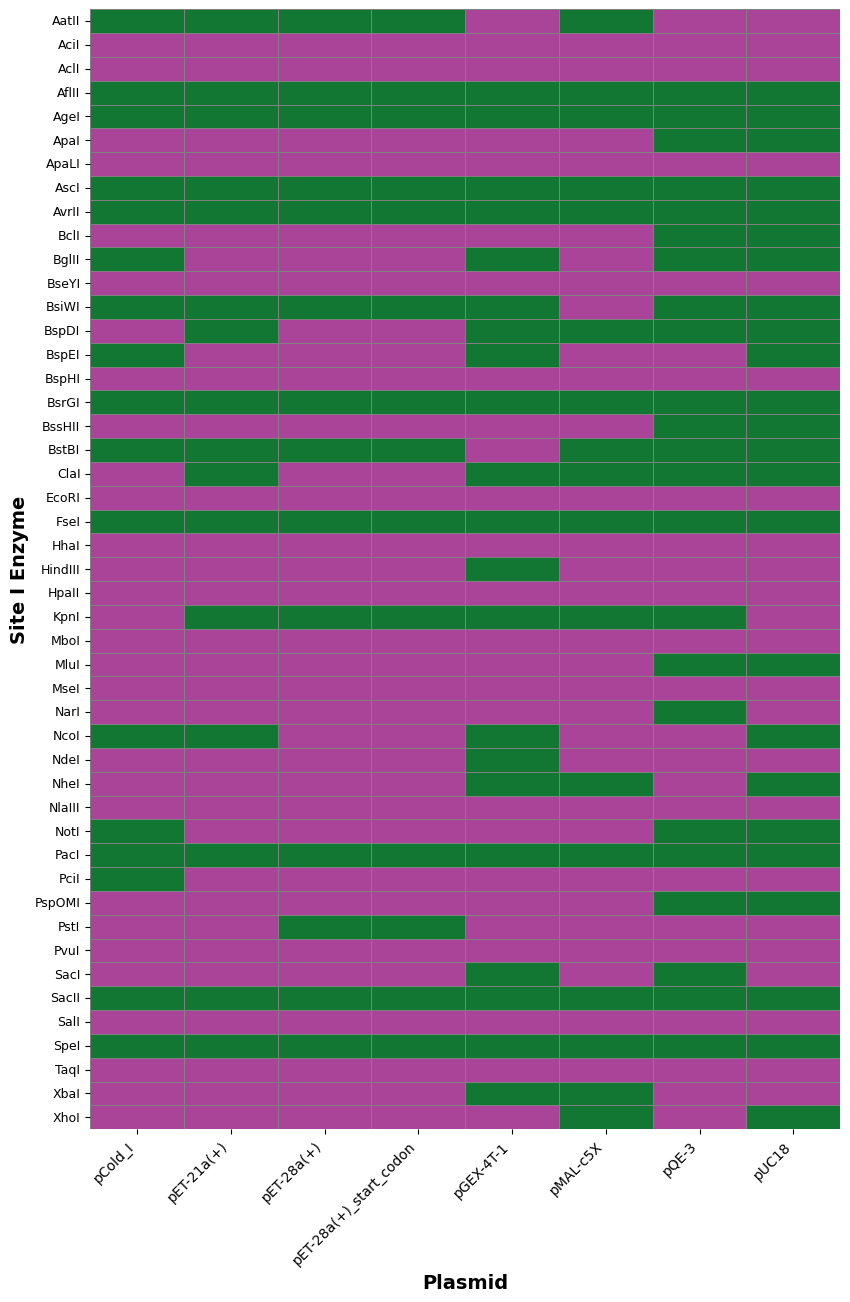

✓ Site I - Plasmid heatmap complete


In [18]:
# Close any existing plots
plt.close('all')

# Plot Site I - Plasmid compatibility heatmap
fig, ax = plt.subplots(figsize=(10, 14))

# Create custom colormap
from matplotlib.colors import ListedColormap
colors_plasmid = ['#AA4499', '#117733']  # Purple for incompatible, green for compatible
cmap_plasmid = ListedColormap(colors_plasmid)

# Create heatmap
sns.heatmap(
    enzyme_plasmid_matrix,
    cmap=cmap_plasmid,
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    square=False,
    ax=ax,
    vmin=0,
    vmax=1
)

# Styling
ax.set_xlabel('Plasmid', fontsize=14, fontweight='bold')
ax.set_ylabel('Site I Enzyme', fontsize=14, fontweight='bold')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.15)
plt.show()

print("✓ Site I - Plasmid heatmap complete")


## Step 14: Site I - Site II Pairing Visualization

Visualize which Site I and Site II enzymes can be paired based on overhang orthogonality

In [25]:
# Group enzymes by overhang for visualization
def group_enzymes_by_ovhg(enzyme_list, ovhg_lookup):
    """Group enzymes by their overhang values"""
    grouped = {}
    for enzyme in enzyme_list:
        ovhg = ovhg_lookup.get(enzyme, 0)
        if ovhg not in grouped:
            grouped[ovhg] = []
        grouped[ovhg].append(enzyme)
    return grouped

# Group Site I and Site II enzymes by overhang
site_i_grouped = group_enzymes_by_ovhg(site_i_enzymes, ovhg_lookup)
site_ii_grouped = group_enzymes_by_ovhg(site_ii_enzymes, ovhg_lookup)

# Sort groups by overhang value
sorted_site_i_enzymes = []
sorted_site_i_ovhgs = []
for ovhg in sorted(site_i_grouped.keys()):
    for enzyme in sorted(site_i_grouped[ovhg]):
        sorted_site_i_enzymes.append(enzyme)
        sorted_site_i_ovhgs.append(ovhg)

sorted_site_ii_enzymes = []
sorted_site_ii_ovhgs = []
for ovhg in sorted(site_ii_grouped.keys()):
    for enzyme in sorted(site_ii_grouped[ovhg]):
        sorted_site_ii_enzymes.append(enzyme)
        sorted_site_ii_ovhgs.append(ovhg)

# Reorder pairing matrix by overhang groups
site_i_ii_matrix_sorted = site_i_ii_matrix.loc[sorted_site_i_enzymes, sorted_site_ii_enzymes]

print(f"✓ Site I enzymes grouped by overhang:")
for ovhg in sorted(site_i_grouped.keys()):
    print(f"  ovhg {int(ovhg):+2d}: {len(site_i_grouped[ovhg])} enzymes")

print(f"\n✓ Site II enzymes grouped by overhang:")
for ovhg in sorted(site_ii_grouped.keys()):
    print(f"  ovhg {int(ovhg):+2d}: {len(site_ii_grouped[ovhg])} enzymes")

✓ Site I enzymes grouped by overhang:
  ovhg -4: 26 enzymes
  ovhg -2: 10 enzymes
  ovhg +2: 4 enzymes
  ovhg +4: 7 enzymes

✓ Site II enzymes grouped by overhang:
  ovhg -4: 26 enzymes
  ovhg +2: 4 enzymes


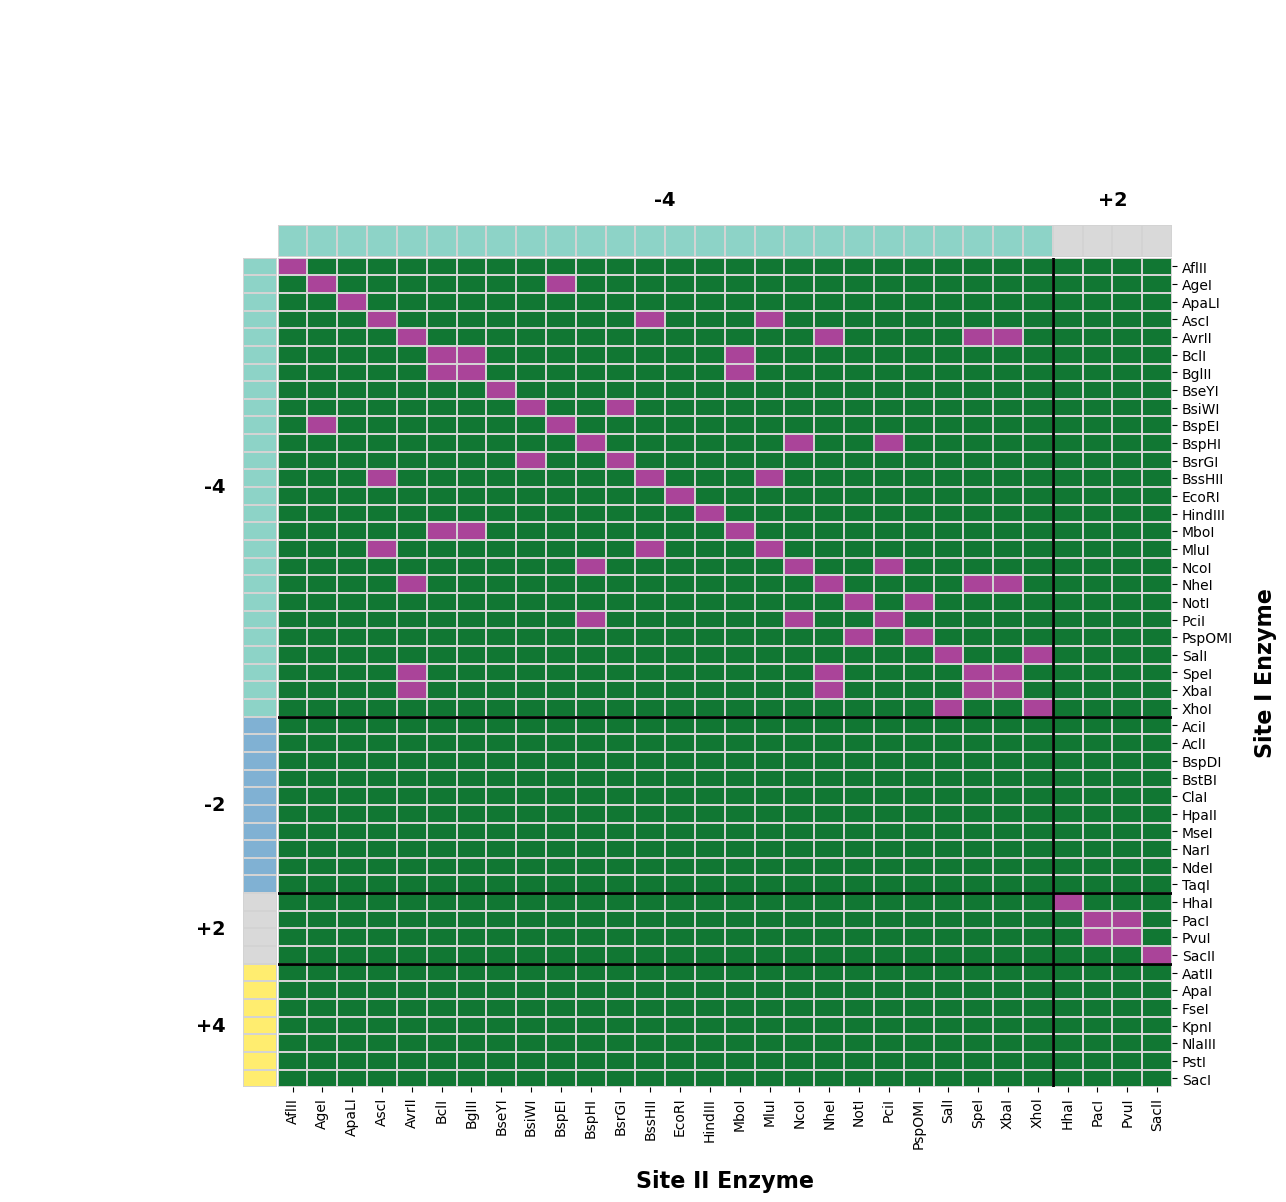

✓ Site I - Site II pairing heatmap complete
  Total pairs: 1,410
  Compatible pairs: 1,340 (95.0%)


In [20]:
# Close any existing plots
plt.close('all')

# Create overhang color maps
unique_ovhgs = sorted(set(sorted_site_i_ovhgs + sorted_site_ii_ovhgs))
ovhg_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_ovhgs)))
ovhg_color_map = dict(zip(unique_ovhgs, ovhg_colors))

# Create row and column colors
row_colors = [ovhg_color_map[ovhg] for ovhg in sorted_site_i_ovhgs]
col_colors = [ovhg_color_map[ovhg] for ovhg in sorted_site_ii_ovhgs]

# Create custom colormap for Site I - Site II
from matplotlib.colors import ListedColormap
colors_i_ii = ['#AA4499', '#117733']  # White for incompatible, green for compatible
cmap_i_ii = ListedColormap(colors_i_ii)

# Plot Site I - Site II pairing heatmap with overhang grouping
g = sns.clustermap(
    site_i_ii_matrix_sorted.astype(int),
    cmap=cmap_i_ii,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=col_colors,
    cbar_pos=None,
    figsize=(14, 14),
    linewidths=0.1,
    linecolor='lightgray',
    vmin=0,
    vmax=1
)

# Style the heatmap
g.ax_heatmap.set_xlabel('Site II Enzyme', fontsize=16, fontweight='bold', labelpad=15)
g.ax_heatmap.set_ylabel('Site I Enzyme', fontsize=16, fontweight='bold', labelpad=15)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

# Add overhang labels to color bars
# Row labels (Site I)
y_positions = []
y_labels = []
y_pos = 0
for ovhg_val in sorted(set(sorted_site_i_ovhgs)):
    count = sorted_site_i_ovhgs.count(ovhg_val)
    y_positions.append(y_pos + count/2)
    y_labels.append(f'{int(ovhg_val):+d}')
    y_pos += count

for y_p, label in zip(y_positions, y_labels):
    g.ax_row_colors.text(-0.5, y_p, label, 
                        va='center', ha='right', fontsize=14, fontweight='bold',
                        transform=g.ax_row_colors.get_yaxis_transform())

# Column labels (Site II)
x_positions = []
x_labels = []
x_pos = 0
for ovhg_val in sorted(set(sorted_site_ii_ovhgs)):
    count = sorted_site_ii_ovhgs.count(ovhg_val)
    x_positions.append(x_pos + count/2)
    x_labels.append(f'{int(ovhg_val):+d}')
    x_pos += count

for x_p, label in zip(x_positions, x_labels):
    g.ax_col_colors.text(x_p, 1.5, label,
                        va='bottom', ha='center', fontsize=14, fontweight='bold',
                        transform=g.ax_col_colors.get_xaxis_transform())

# Add separator lines between overhang groups
y_pos = 0
for ovhg_val in sorted(set(sorted_site_i_ovhgs))[:-1]:
    count = sorted_site_i_ovhgs.count(ovhg_val)
    y_pos += count
    g.ax_heatmap.axhline(y=y_pos, color='black', linewidth=2, zorder=10)

x_pos = 0
for ovhg_val in sorted(set(sorted_site_ii_ovhgs))[:-1]:
    count = sorted_site_ii_ovhgs.count(ovhg_val)
    x_pos += count
    g.ax_heatmap.axvline(x=x_pos, color='black', linewidth=2, zorder=10)

plt.subplots_adjust(left=0.15, right=0.98, top=0.92, bottom=0.15)
plt.show()

print("✓ Site I - Site II pairing heatmap complete")
print(f"  Total pairs: {total_pairs:,}")
print(f"  Compatible pairs: {compatible_pairs:,} ({compatible_pairs/total_pairs*100:.1f}%)")

## Step 15: Site II - Site III Pairing Visualization

Visualize which Site II and Site III enzymes can be paired (same overhang required)

In [21]:
# Build Site II - Site III pairing matrix
# Rule: can only pair if they have the SAME overhang (including sign)

site_iii_enzymes = SITE_III_ENZYMES
print(f"Building Site II - Site III pairing matrix...")
print(f"  Site II enzymes: {len(site_ii_enzymes)}")
print(f"  Site III enzymes: {len(site_iii_enzymes)}")

# Create pairing matrix
site_ii_iii_matrix = pd.DataFrame(
    index=site_ii_enzymes,
    columns=site_iii_enzymes,
    dtype=bool
)

# Fill matrix: compatible only if same overhang
for enzyme_ii in site_ii_enzymes:
    ovhg_ii = ovhg_lookup.get(enzyme_ii, None)
    for enzyme_iii in site_iii_enzymes:
        ovhg_iii = ovhg_lookup.get(enzyme_iii, None)
        # Compatible only if same overhang (sign matters: +2 ≠ -2)
        site_ii_iii_matrix.loc[enzyme_ii, enzyme_iii] = (ovhg_ii == ovhg_iii)

# Statistics
total_pairs_ii_iii = len(site_ii_enzymes) * len(site_iii_enzymes)
compatible_pairs_ii_iii = site_ii_iii_matrix.sum().sum()

print(f"✓ Site II - Site III matrix built:")
print(f"  Total pairs: {total_pairs_ii_iii:,}")
print(f"  Compatible pairs: {compatible_pairs_ii_iii:,} ({compatible_pairs_ii_iii/total_pairs_ii_iii*100:.1f}%)")

Building Site II - Site III pairing matrix...
  Site II enzymes: 30
  Site III enzymes: 18
✓ Site II - Site III matrix built:
  Total pairs: 540
  Compatible pairs: 218 (40.4%)


In [26]:
# Group Site III enzymes by overhang
site_iii_grouped = group_enzymes_by_ovhg(site_iii_enzymes, ovhg_lookup)

# Sort Site III enzymes by overhang
sorted_site_iii_enzymes = []
sorted_site_iii_ovhgs = []
for ovhg in sorted(site_iii_grouped.keys()):
    for enzyme in sorted(site_iii_grouped[ovhg]):
        sorted_site_iii_enzymes.append(enzyme)
        sorted_site_iii_ovhgs.append(ovhg)

# Reorder matrix by overhang groups
site_ii_iii_matrix_sorted = site_ii_iii_matrix.loc[sorted_site_ii_enzymes, sorted_site_iii_enzymes]

print(f"✓ Site III enzymes grouped by overhang:")
for ovhg in sorted(site_iii_grouped.keys()):
    print(f"  ovhg {int(ovhg):+2d}: {len(site_iii_grouped[ovhg])} enzymes")
    print(f"    Enzymes: {', '.join(sorted(site_iii_grouped[ovhg]))}")

✓ Site III enzymes grouped by overhang:
  ovhg -4: 7 enzymes
    Enzymes: BbsI, BcoDI, BsaI, BsmAI, BsmBI, BspMI, Esp3I
  ovhg -3: 2 enzymes
    Enzymes: EarI, SapI
  ovhg +2: 9 enzymes
    Enzymes: BpuEI, BseRI, BsgI, BsmI, BspCNI, BsrI, BtsCI, BtsIMutI, NmeAIII


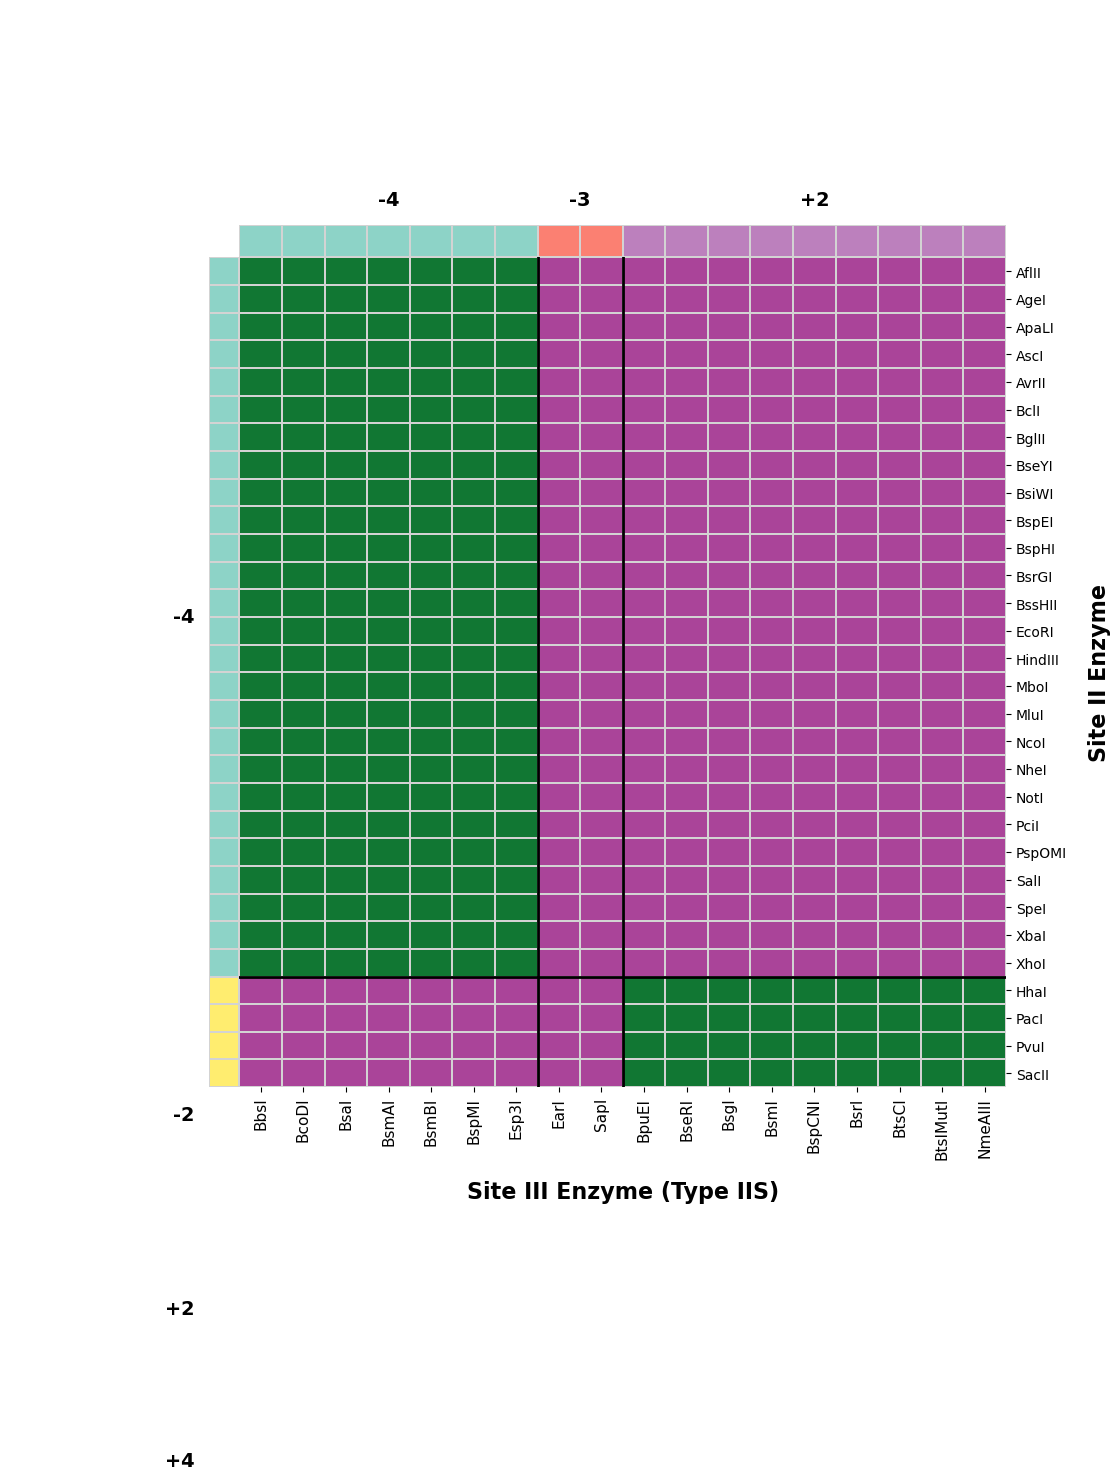

✓ Site II - Site III pairing heatmap complete
  Total pairs: 540
  Compatible pairs: 218 (40.4%)

Note: Site II and Site III can only pair if they have the SAME overhang
      This ensures proper ligation in Golden Gate assembly


In [23]:
# Close any existing plots
plt.close('all')

# Create colors for Site III
# Need to update color map to include Site III overhangs
all_ovhgs = sorted(set(sorted_site_i_ovhgs + sorted_site_ii_ovhgs + sorted_site_iii_ovhgs))
ovhg_colors_all = plt.cm.Set3(np.linspace(0, 1, len(all_ovhgs)))
ovhg_color_map_all = dict(zip(all_ovhgs, ovhg_colors_all))

col_colors_iii = [ovhg_color_map_all[ovhg] for ovhg in sorted_site_iii_ovhgs]

# Create custom colormap for Site II - Site III
from matplotlib.colors import ListedColormap
colors_ii_iii = ['#AA4499', '#117733']  # White for incompatible, red for compatible
cmap_ii_iii = ListedColormap(colors_ii_iii)

# Plot Site II - Site III pairing heatmap
g2 = sns.clustermap(
    site_ii_iii_matrix_sorted.astype(int),
    cmap=cmap_ii_iii,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,  # Same row colors as before (Site II)
    col_colors=col_colors_iii,  # Site III colors
    cbar_pos=None,
    figsize=(12, 14),
    linewidths=0.1,
    linecolor='lightgray',
    vmin=0,
    vmax=1
)

# Style the heatmap
g2.ax_heatmap.set_xlabel('Site III Enzyme (Type IIS)', fontsize=16, fontweight='bold', labelpad=15)
g2.ax_heatmap.set_ylabel('Site II Enzyme', fontsize=16, fontweight='bold', labelpad=15)
plt.setp(g2.ax_heatmap.get_xticklabels(), rotation=90, fontsize=11)
plt.setp(g2.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

# Add overhang labels to row colors (Site II - reuse from before)
for y_p, label in zip(y_positions, y_labels):
    g2.ax_row_colors.text(-0.5, y_p, label, 
                         va='center', ha='right', fontsize=14, fontweight='bold',
                         transform=g2.ax_row_colors.get_yaxis_transform())

# Add overhang labels to column colors (Site III)
x_positions_iii = []
x_labels_iii = []
x_pos = 0
for ovhg_val in sorted(set(sorted_site_iii_ovhgs)):
    count = sorted_site_iii_ovhgs.count(ovhg_val)
    x_positions_iii.append(x_pos + count/2)
    x_labels_iii.append(f'{int(ovhg_val):+d}')
    x_pos += count

for x_p, label in zip(x_positions_iii, x_labels_iii):
    g2.ax_col_colors.text(x_p, 1.5, label,
                         va='bottom', ha='center', fontsize=14, fontweight='bold',
                         transform=g2.ax_col_colors.get_xaxis_transform())

# Add separator lines between overhang groups (rows)
y_pos = 0
for ovhg_val in sorted(set(sorted_site_ii_ovhgs))[:-1]:
    count = sorted_site_ii_ovhgs.count(ovhg_val)
    y_pos += count
    g2.ax_heatmap.axhline(y=y_pos, color='black', linewidth=2, zorder=10)

# Add separator lines between overhang groups (columns)
x_pos = 0
for ovhg_val in sorted(set(sorted_site_iii_ovhgs))[:-1]:
    count = sorted_site_iii_ovhgs.count(ovhg_val)
    x_pos += count
    g2.ax_heatmap.axvline(x=x_pos, color='black', linewidth=2, zorder=10)

plt.subplots_adjust(left=0.15, right=0.98, top=0.92, bottom=0.15)
plt.show()

print("✓ Site II - Site III pairing heatmap complete")
print(f"  Total pairs: {total_pairs_ii_iii:,}")
print(f"  Compatible pairs: {compatible_pairs_ii_iii:,} ({compatible_pairs_ii_iii/total_pairs_ii_iii*100:.1f}%)")
print(f"\nNote: Site II and Site III can only pair if they have the SAME overhang")
print(f"      This ensures proper ligation in Golden Gate assembly")

## Summary

This standalone notebook demonstrates the complete HURDLER pipeline without external files:

1. **Generated enzyme database** from Biopython restriction enzyme library
2. **Created seamless insert data** by generating 9bp sequences containing RE sites
3. **Created silent mutation data** by finding single mutations that preserve amino acid sequence
4. **Selected high-quality enzymes** based on curated lists
5. **Built RE pairing matrix** for compatible enzyme combinations
6. **Generated lookup dataframe** with pattern-based matching
7. **Tested success rates** on random sequences

**Note**: This demo version uses reduced data (100 enzyme pairs, 7-20 AA testing) for fast execution. The full version would process all compatible pairs and test 7-60 AA with 1000 tests per length.